# PS S6E6 037: TabICL v2 as-is

Experiment: `exp_20260610_037_tabicl_v2_as_is`

Purpose:

- Run the shared `tabicl-v2-for-s6e6` notebook as-is in the current experiment format.
- Use only the S6E6 competition dataset.
- Use raw S6E6 feature table, no handcrafted FE.
- Save OOF / test probabilities for later blend/correlation check.
- This is a diversity-material experiment. The source notebook does not provide a confirmed Public LB; this run will submit our own output if needed.


In [1]:
# 0. Installation
!pip -q install tabicl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.9/252.9 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 111.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu1

In [2]:
# 1. Imports and experiment configuration
import os
import gc
import json
import glob
import time
import warnings
from pathlib import Path
from datetime import datetime

os.environ.setdefault('TOKENIZERS_PARALLELISM', 'false')
os.environ.setdefault('WANDB_DISABLED', 'true')

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from tabicl import TabICLClassifier

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)

EXP_ID = 'exp_20260610_037_tabicl_v2_as_is'
CREATED_AT = '2026-06-10'
COMPETITION = 'PS S6E6 Predicting Stellar Class'

class CFG:
    MODEL_ID = '037_tabicl_v2'
    SEED = 42
    N_FOLDS = 5
    TARGET = 'class'
    ID = 'id'
    CLASSES = ['GALAXY', 'QSO', 'STAR']
    TARGET_MAP = {c: i for i, c in enumerate(CLASSES)}
    INV_TARGET_MAP = {i: c for c, i in TARGET_MAP.items()}
    N_CLASSES = len(CLASSES)

    # Chris/TabICL v2 style: balanced 30,000-row context sample per fold.
    SAMPLES_PER_CLASS = 10000

    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
    TABICL_PARAMS = {
        'n_estimators': 8,
        'batch_size': 1,
        'device': DEVICE,
        'use_amp': 'auto',
        'random_state': SEED,
        'verbose': False,
    }

print('EXP_ID:', EXP_ID)
print('torch:', torch.__version__)
print('cuda available:', torch.cuda.is_available())
print('TabICL device:', CFG.DEVICE)

EXP_ID: exp_20260610_037_tabicl_v2_as_is
torch: 2.10.0+cu128
cuda available: True
TabICL device: cuda


In [3]:
# 2. Strict S6E6 data loading
def find_competition_root():
    # Keep this strict to avoid accidentally reading another competition dataset.
    candidates = [
        Path('/kaggle/input/playground-series-s6e6'),
        Path('/kaggle/input/competitions/playground-series-s6e6'),
        Path('/mnt/data/playground-series-s6e6'),
    ]
    for root in candidates:
        if (root / 'train.csv').exists() and (root / 'test.csv').exists() and (root / 'sample_submission.csv').exists():
            return root
    raise FileNotFoundError(
        'Could not find S6E6 train.csv/test.csv/sample_submission.csv. '
        'Please add the Playground Series S6E6 competition dataset as notebook input.'
    )

DATA_ROOT = find_competition_root()
train_raw = pd.read_csv(DATA_ROOT / 'train.csv')
test_raw = pd.read_csv(DATA_ROOT / 'test.csv')
sample = pd.read_csv(DATA_ROOT / 'sample_submission.csv')

# Safety checks to prevent wrong-dataset execution.
assert CFG.ID in train_raw.columns, 'train.csv must contain id column'
assert CFG.TARGET in train_raw.columns, 'train.csv must contain class target column'
assert CFG.ID in test_raw.columns, 'test.csv must contain id column'
assert list(sample.columns) == [CFG.ID, CFG.TARGET], 'sample_submission.csv must have columns [id, class]'
assert set(train_raw[CFG.TARGET].unique()).issubset(set(CFG.CLASSES)), f'Unexpected target labels: {train_raw[CFG.TARGET].unique()}'

test_ids = test_raw[CFG.ID].to_numpy()
y_raw_labels = train_raw[CFG.TARGET].copy()
train_raw[CFG.TARGET] = train_raw[CFG.TARGET].map(CFG.TARGET_MAP).astype('int8')

print(f'competition root: {DATA_ROOT}')
print(f'train_raw: {train_raw.shape} | test_raw: {test_raw.shape} | sample: {sample.shape}')
print('Target counts:')
display(y_raw_labels.value_counts().reindex(CFG.CLASSES).rename('count').to_frame())
print('Target ratio:')
display(y_raw_labels.value_counts(normalize=True).reindex(CFG.CLASSES).rename('ratio').to_frame())

competition root: /kaggle/input/competitions/playground-series-s6e6
train_raw: (577347, 12) | test_raw: (247435, 11) | sample: (247435, 2)
Target counts:


,count
class,
GALAXY,377480
QSO,117143
STAR,82724


Target ratio:


,ratio
class,
GALAXY,0.653818
QSO,0.202899
STAR,0.143283


In [4]:
# 3. Raw feature table
print('Using raw S6E6 feature table. No additional FE.')

def make_feature_table(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy()
    if CFG.ID in d.columns:
        d = d.drop(columns=[CFG.ID])
    return d

train_fe = make_feature_table(train_raw)
test_fe = make_feature_table(test_raw)

FEATURES = [c for c in train_fe.columns if c != CFG.TARGET]
y_train = train_fe[CFG.TARGET].to_numpy().astype('int8')

# Downcast numeric columns for memory.
for frame in [train_fe, test_fe]:
    for c in frame.select_dtypes(include=['float64']).columns:
        frame[c] = frame[c].astype('float32')
    for c in frame.select_dtypes(include=['int64']).columns:
        frame[c] = frame[c].astype('int32')

# Defensive check: train/test feature columns must match.
assert FEATURES == list(test_fe.columns), 'train/test feature columns mismatch after preprocessing'

print(f'n_features: {len(FEATURES)}')
print(FEATURES)
display(train_fe[FEATURES].head())

Using raw S6E6 feature table. No additional FE.
n_features: 10
['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'spectral_type', 'galaxy_population']


,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population
0,147.734253,16.959272,25.472122,21.895559,20.357925,19.257113,18.621058,0.408982,M,Red_Sequence
1,127.988678,32.346718,20.778509,19.087063,17.587208,17.226067,16.786432,0.157976,M,Red_Sequence
2,179.792648,35.344845,21.035202,21.079128,21.171841,20.582630,20.557365,2.823770,O/B,Blue_Cloud
3,225.818298,48.569420,23.305056,21.050735,19.017754,18.365658,17.914951,0.536099,M,Red_Sequence
4,141.836136,19.342852,21.703157,19.471680,18.234449,17.899446,17.616184,0.555761,M,Red_Sequence


In [5]:
# 4. Strategic balanced context CV inference
print(f'Inference mode: up to {CFG.SAMPLES_PER_CLASS * CFG.N_CLASSES:,} context rows per fold')

def cleanup_cuda():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

def normalize_proba(p: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    p = np.asarray(p, dtype='float32')
    p = np.clip(p, eps, None)
    p = p / p.sum(axis=1, keepdims=True)
    return p.astype('float32')

skf = StratifiedKFold(n_splits=CFG.N_FOLDS, shuffle=True, random_state=CFG.SEED)
oof_probs = np.zeros((len(train_fe), CFG.N_CLASSES), dtype='float32')
test_probs_sum = np.zeros((len(test_fe), CFG.N_CLASSES), dtype='float32')
fold_rows = []

X_all = train_fe[FEATURES]
X_test = test_fe[FEATURES]

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_all, y_train), start=1):
    start_time = time.time()

    # Balanced context sampling from the current training fold only.
    context_indices = []
    per_class_context_counts = {}
    for c in range(CFG.N_CLASSES):
        c_train_idx = tr_idx[y_train[tr_idx] == c]
        rng = np.random.default_rng(CFG.SEED + fold * 100 + c)
        n_take = min(len(c_train_idx), CFG.SAMPLES_PER_CLASS)
        sampled = rng.choice(c_train_idx, size=n_take, replace=False)
        context_indices.extend(sampled.tolist())
        per_class_context_counts[CFG.INV_TARGET_MAP[c]] = int(n_take)

    rng = np.random.default_rng(CFG.SEED + fold * 1000)
    context_indices = np.array(context_indices, dtype=np.int64)
    rng.shuffle(context_indices)

    X_context = X_all.iloc[context_indices]
    y_context = y_train[context_indices]
    X_va = X_all.iloc[va_idx]
    y_va = y_train[va_idx]

    clf = TabICLClassifier(**CFG.TABICL_PARAMS)
    clf.fit(X_context, y_context)

    va_proba = normalize_proba(clf.predict_proba(X_va))
    te_proba = normalize_proba(clf.predict_proba(X_test))

    oof_probs[va_idx] = va_proba
    test_probs_sum += te_proba / CFG.N_FOLDS

    fold_pred = np.argmax(va_proba, axis=1)
    fold_ba = balanced_accuracy_score(y_va, fold_pred)
    elapsed = time.time() - start_time
    row = {
        'fold': fold,
        'balanced_accuracy': float(fold_ba),
        'context_size': int(len(context_indices)),
        'n_train_fold': int(len(tr_idx)),
        'n_valid': int(len(va_idx)),
        'n_estimators': int(CFG.TABICL_PARAMS['n_estimators']),
        'samples_per_class': int(CFG.SAMPLES_PER_CLASS),
        'elapsed_sec': float(elapsed),
    }
    for k, v in per_class_context_counts.items():
        row[f'context_{k}'] = v
    fold_rows.append(row)

    print(f'Fold {fold} | BA: {fold_ba:.8f} | context: {len(context_indices):,} | {elapsed:.1f}s')

    del clf, X_context, y_context, X_va, y_va, va_proba, te_proba
    cleanup_cuda()

test_probs_sum = normalize_proba(test_probs_sum)
fold_scores = pd.DataFrame(fold_rows)
overall_cv = balanced_accuracy_score(y_train, np.argmax(oof_probs, axis=1))

print()
print('Fold scores:')
display(fold_scores)
print(f'CV Balanced ACC (OOF): {overall_cv:.8f}')
print(f"Mean Fold ACC: {fold_scores['balanced_accuracy'].mean():.8f} +/- {fold_scores['balanced_accuracy'].std(ddof=0):.8f}")

Inference mode: up to 30,000 context rows per fold
INFO: You are downloading 'tabicl-classifier-v2-20260212.ckpt', the latest best-performing version, used in our TabICLv2 paper.

Checkpoint 'tabicl-classifier-v2-20260212.ckpt' not cached.



tabicl-classifier-v2-20260212.ckpt:   0%|          | 0.00/110M [00:00<?, ?B/s]

Fold 1 | BA: 0.95769081 | context: 30,000 | 268.0s
Fold 2 | BA: 0.95844869 | context: 30,000 | 271.2s
Fold 3 | BA: 0.95752837 | context: 30,000 | 271.3s
Fold 4 | BA: 0.95792674 | context: 30,000 | 271.2s
Fold 5 | BA: 0.95879044 | context: 30,000 | 271.2s

Fold scores:


,fold,balanced_accuracy,context_size,n_train_fold,n_valid,n_estimators,samples_per_class,elapsed_sec,context_GALAXY,context_QSO,context_STAR
0,1,0.957691,30000,461877,115470,8,10000,267.970007,10000,10000,10000
1,2,0.958449,30000,461877,115470,8,10000,271.228391,10000,10000,10000
2,3,0.957528,30000,461878,115469,8,10000,271.270707,10000,10000,10000
3,4,0.957927,30000,461878,115469,8,10000,271.174217,10000,10000,10000
4,5,0.958790,30000,461878,115469,8,10000,271.156281,10000,10000,10000


CV Balanced ACC (OOF): 0.95807702
Mean Fold ACC: 0.95807701 +/- 0.00047326


Overall CV Balanced Accuracy: 0.95807702
OOF recalls: {'GALAXY': 0.9414220620960051, 'QSO': 0.9708390599523659, 'STAR': 0.9619699240849089}


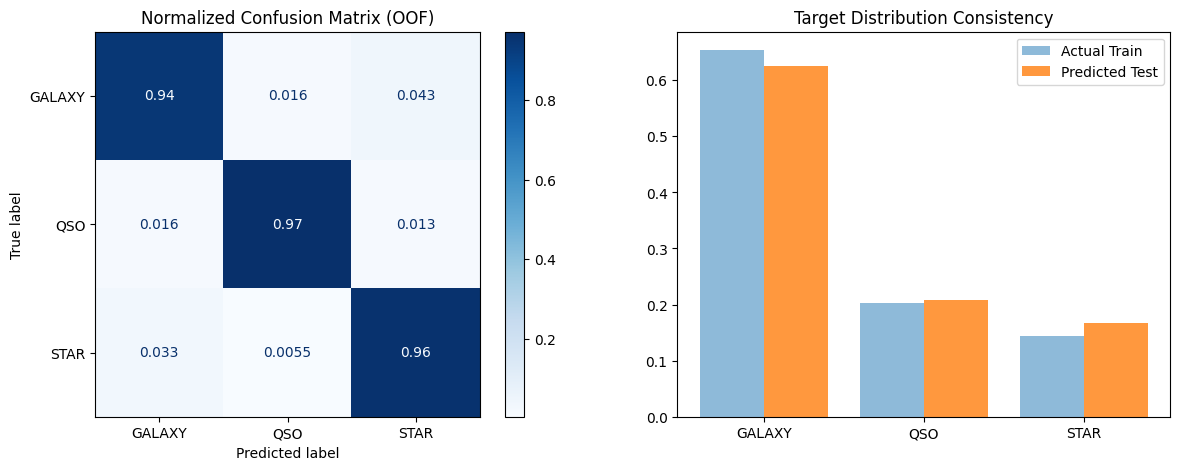

,class,train_count,train_ratio,submission_count,submission_ratio
0,GALAXY,377480,0.653818,154528,0.624520
1,QSO,117143,0.202899,51441,0.207897
2,STAR,82724,0.143283,41466,0.167583


In [6]:
# 5. Result diagnostics
oof_pred = np.argmax(oof_probs, axis=1)
test_pred = np.argmax(test_probs_sum, axis=1)
recalls = {}
for i, name in enumerate(CFG.CLASSES):
    mask = y_train == i
    recalls[name] = float((oof_pred[mask] == i).mean())

print(f'Overall CV Balanced Accuracy: {overall_cv:.8f}')
print('OOF recalls:', recalls)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(
    y_train,
    oof_pred,
    display_labels=CFG.CLASSES,
    cmap='Blues',
    normalize='true',
    ax=ax[0],
)
ax[0].set_title('Normalized Confusion Matrix (OOF)')

train_dist = pd.Series(y_train).map(CFG.INV_TARGET_MAP).value_counts(normalize=True).reindex(CFG.CLASSES, fill_value=0)
test_dist = pd.Series(test_pred).map(CFG.INV_TARGET_MAP).value_counts(normalize=True).reindex(CFG.CLASSES, fill_value=0)
x = np.arange(CFG.N_CLASSES)
ax[1].bar(x - 0.2, train_dist.values, 0.4, label='Actual Train', alpha=0.5)
ax[1].bar(x + 0.2, test_dist.values, 0.4, label='Predicted Test', alpha=0.8)
ax[1].set_xticks(x)
ax[1].set_xticklabels(CFG.CLASSES)
ax[1].legend()
ax[1].set_title('Target Distribution Consistency')
plt.show()

submission_dist = pd.Series(test_pred).map(CFG.INV_TARGET_MAP).value_counts().reindex(CFG.CLASSES, fill_value=0)
class_distribution = pd.DataFrame({
    'class': CFG.CLASSES,
    'train_count': [int((y_train == i).sum()) for i in range(CFG.N_CLASSES)],
    'train_ratio': [float((y_train == i).mean()) for i in range(CFG.N_CLASSES)],
    'submission_count': [int(submission_dist.loc[name]) for name in CFG.CLASSES],
    'submission_ratio': [float(submission_dist.loc[name] / len(test_pred)) for name in CFG.CLASSES],
})
display(class_distribution)

In [7]:
# 6. Save artifacts
OUTPUT_DIR = Path('.')

OOF_NPY = OUTPUT_DIR / f'oof_{EXP_ID}_proba.npy'
PRED_NPY = OUTPUT_DIR / f'pred_{EXP_ID}_proba.npy'
OOF_CSV = OUTPUT_DIR / f'oof_{EXP_ID}.csv'
PRED_CSV = OUTPUT_DIR / f'pred_{EXP_ID}.csv'
SUB_CSV = OUTPUT_DIR / f'submission_{EXP_ID}.csv'
CV_JSON = OUTPUT_DIR / f'cv_result_{EXP_ID}.json'
FOLD_CSV = OUTPUT_DIR / f'fold_scores_{EXP_ID}.csv'
FEATURE_INFO_JSON = OUTPUT_DIR / f'feature_info_{EXP_ID}.json'
FEATURE_COLUMNS_CSV = OUTPUT_DIR / f'feature_columns_{EXP_ID}.csv'
CLASS_DIST_CSV = OUTPUT_DIR / f'class_distribution_{EXP_ID}.csv'
REGISTRY_CSV = OUTPUT_DIR / 'oof_registry.csv'
MEMO_YML = OUTPUT_DIR / 'memo.yml'

np.save(OOF_NPY, oof_probs.astype('float32'))
np.save(PRED_NPY, test_probs_sum.astype('float32'))

oof_df = pd.DataFrame(oof_probs, columns=[f'proba_{c}' for c in CFG.CLASSES])
oof_df.insert(0, CFG.ID, train_raw[CFG.ID].values)
oof_df.insert(1, CFG.TARGET, y_raw_labels.values)
oof_df['pred'] = [CFG.INV_TARGET_MAP[i] for i in oof_pred]
oof_df.to_csv(OOF_CSV, index=False)

pred_df = pd.DataFrame(test_probs_sum, columns=[f'proba_{c}' for c in CFG.CLASSES])
pred_df.insert(0, CFG.ID, test_ids)
pred_df['pred'] = [CFG.INV_TARGET_MAP[i] for i in test_pred]
pred_df.to_csv(PRED_CSV, index=False)

submission = sample.copy()
submission[CFG.TARGET] = [CFG.INV_TARGET_MAP[i] for i in test_pred]
submission.to_csv(SUB_CSV, index=False)

fold_scores.to_csv(FOLD_CSV, index=False)
pd.DataFrame({'feature': FEATURES}).to_csv(FEATURE_COLUMNS_CSV, index=False)
class_distribution.to_csv(CLASS_DIST_CSV, index=False)

feature_info = {
    'exp_id': EXP_ID,
    'n_features': len(FEATURES),
    'features': FEATURES,
    'feature_engineering': 'raw_s6e6_feature_table_only',
    'dropped_columns': [CFG.ID],
    'target': CFG.TARGET,
}
FEATURE_INFO_JSON.write_text(json.dumps(feature_info, indent=2, ensure_ascii=False), encoding='utf-8')

cv_result = {
    'exp_id': EXP_ID,
    'competition': COMPETITION,
    'created_at': CREATED_AT,
    'status': 'completed',
    'metric': 'balanced_accuracy_score',
    'model_family': 'TabICL',
    'model_type': 'tabicl_v2_as_is_raw_features_balanced_context',
    'cv_score': float(overall_cv),
    'fold_mean': float(fold_scores['balanced_accuracy'].mean()),
    'fold_std': float(fold_scores['balanced_accuracy'].std(ddof=0)),
    'recalls': recalls,
    'n_splits': CFG.N_FOLDS,
    'seed': CFG.SEED,
    'use_original': False,
    'use_fe': False,
    'use_bias_search': False,
    'use_external_stacking_files': False,
    'public_lb_from_source_not_available': True,
    'source_notebook_lb_note': 'Source notebook appears to be shared as blend material / reference. No confirmed source LB is assumed.',
    'config': {
        'samples_per_class': CFG.SAMPLES_PER_CLASS,
        'max_context_size_per_fold': CFG.SAMPLES_PER_CLASS * CFG.N_CLASSES,
        'tabicl_params': CFG.TABICL_PARAMS,
        'device': CFG.DEVICE,
    },
    'outputs': {
        'oof_proba': OOF_NPY.name,
        'pred_proba': PRED_NPY.name,
        'oof_csv': OOF_CSV.name,
        'pred_csv': PRED_CSV.name,
        'submission': SUB_CSV.name,
        'cv_result': CV_JSON.name,
        'fold_scores': FOLD_CSV.name,
        'feature_info': FEATURE_INFO_JSON.name,
        'feature_columns': FEATURE_COLUMNS_CSV.name,
        'class_distribution': CLASS_DIST_CSV.name,
    },
}
CV_JSON.write_text(json.dumps(cv_result, indent=2, ensure_ascii=False), encoding='utf-8')

registry_row = {
    'exp_id': EXP_ID,
    'key': '037_tabicl_v2',
    'family': 'TabICL',
    'role': 'tabicl_v2_raw_feature_aux_material',
    'oof': OOF_NPY.name,
    'pred': PRED_NPY.name,
    'cv': float(overall_cv),
    'public_lb': np.nan,
    'optional': False,
    'created_at': CREATED_AT,
}
if REGISTRY_CSV.exists():
    reg = pd.read_csv(REGISTRY_CSV)
    reg = reg[reg['exp_id'] != EXP_ID]
    reg = pd.concat([reg, pd.DataFrame([registry_row])], ignore_index=True)
else:
    reg = pd.DataFrame([registry_row])
reg.to_csv(REGISTRY_CSV, index=False)

memo = {
    'exp_id': EXP_ID,
    'created_at': CREATED_AT,
    'competition': COMPETITION,
    'status': 'completed',
    'purpose': 'Run TabICL v2 as-is using raw S6E6 features and save OOF/pred probabilities for blend/correlation check.',
    'result': {
        'cv_balanced_accuracy': float(overall_cv),
        'fold_mean': float(fold_scores['balanced_accuracy'].mean()),
        'fold_std': float(fold_scores['balanced_accuracy'].std(ddof=0)),
        'public_lb': None,
        'submitted': False,
    },
    'model_summary': {
        'model_family': 'TabICL',
        'model_type': 'tabicl_v2_as_is_raw_features_balanced_context',
        'use_original': False,
        'use_fe': False,
        'use_bias_search': False,
        'use_external_stacking_files': False,
        'source_public_lb_available': False,
        'source_public_lb_note': 'No source LB is assumed for this notebook. Treat as diversity material.',
        'seed': CFG.SEED,
        'n_splits': CFG.N_FOLDS,
        'samples_per_class': CFG.SAMPLES_PER_CLASS,
        'max_context_size_per_fold': CFG.SAMPLES_PER_CLASS * CFG.N_CLASSES,
        'tabicl_params': CFG.TABICL_PARAMS,
    },
    'cv': {
        'score': float(overall_cv),
        'fold_std': float(fold_scores['balanced_accuracy'].std(ddof=0)),
        'recalls': recalls,
    },
    'outputs': cv_result['outputs'],
    'judgement': {
        'keep_hold_drop': 'keep_for_038_blend_corr_check',
        'role': 'tabicl_v2_raw_feature_aux_material',
        'not_for_submission_slot_until_lb_checked': True,
        'next_action': [
            'Submit 037 only if a standalone LB check is desired.',
            'Add OOF/pred npy to npy-files dataset.',
            'Run 038 add037 blend/corr check against 033, 036 GPU LogReg add035, 036 blend add035, 034, 031, 029, 028, 030, 032, and 035.',
        ],
    },
}
try:
    import yaml
    MEMO_YML.write_text(yaml.safe_dump(memo, sort_keys=False, allow_unicode=True), encoding='utf-8')
except Exception:
    # Fallback: JSON-compatible YAML subset.
    MEMO_YML.write_text(json.dumps(memo, indent=2, ensure_ascii=False), encoding='utf-8')

print('Saved artifacts:')
for p in [OOF_NPY, PRED_NPY, OOF_CSV, PRED_CSV, SUB_CSV, CV_JSON, FOLD_CSV, FEATURE_INFO_JSON, FEATURE_COLUMNS_CSV, CLASS_DIST_CSV, REGISTRY_CSV, MEMO_YML]:
    print(' ', p)

display(submission.head())

Saved artifacts:
  oof_exp_20260610_037_tabicl_v2_as_is_proba.npy
  pred_exp_20260610_037_tabicl_v2_as_is_proba.npy
  oof_exp_20260610_037_tabicl_v2_as_is.csv
  pred_exp_20260610_037_tabicl_v2_as_is.csv
  submission_exp_20260610_037_tabicl_v2_as_is.csv
  cv_result_exp_20260610_037_tabicl_v2_as_is.json
  fold_scores_exp_20260610_037_tabicl_v2_as_is.csv
  feature_info_exp_20260610_037_tabicl_v2_as_is.json
  feature_columns_exp_20260610_037_tabicl_v2_as_is.csv
  class_distribution_exp_20260610_037_tabicl_v2_as_is.csv
  oof_registry.csv
  memo.yml


,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,STAR
4,577351,GALAXY
